In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

In [2]:
#laod and preprocess data

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Training Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))

Training Samples: 60000
Testing Samples: 10000


In [3]:
#create laoders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [4]:
#defining CNN model

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(
                7 * 7 * 64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                10
            )
        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = x.view(x.size(0), -1)

        x = self.fc_layers(x)

        return x

In [5]:
model = CNN()

print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
#loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [7]:
#training
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/5] Loss: 0.1582
Epoch [2/5] Loss: 0.0467
Epoch [3/5] Loss: 0.0319
Epoch [4/5] Loss: 0.0239
Epoch [5/5] Loss: 0.0188


In [8]:
#Evaluate accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.06%


In [9]:
#Sample predictions
images, labels = next(iter(test_loader))

outputs = model(images)

_, predicted = torch.max(outputs, 1)

for i in range(10):
    print(
        f"Actual: {labels[i].item()} | "
        f"Predicted: {predicted[i].item()}"
    )

Actual: 7 | Predicted: 7
Actual: 2 | Predicted: 2
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 4 | Predicted: 4
Actual: 1 | Predicted: 1
Actual: 4 | Predicted: 4
Actual: 9 | Predicted: 9
Actual: 5 | Predicted: 5
Actual: 9 | Predicted: 9


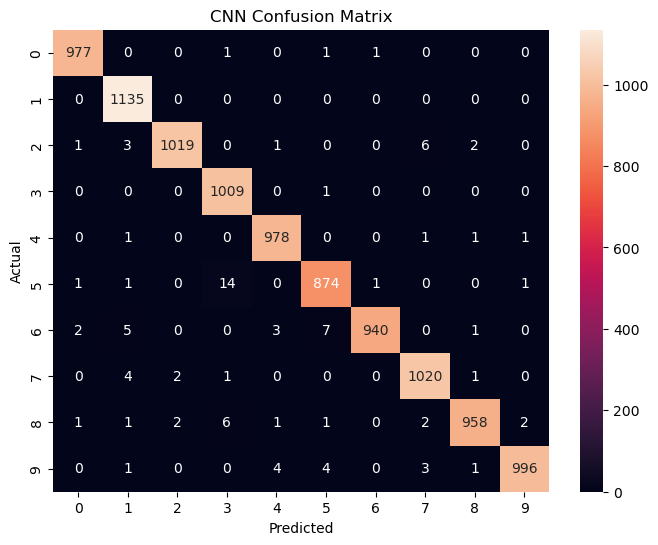

In [12]:
#Evaluation
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()